## Домашнее задание №2

Скачиваем данные


In [ ]:
!wget https://github.com/yutkin/Lenta.Ru-News-Dataset/releases/download/v1.0/lenta-ru-news.csv.gz

--2026-03-19 09:54:48--  https://github.com/yutkin/Lenta.Ru-News-Dataset/releases/download/v1.0/lenta-ru-news.csv.gz
Resolving github.com (github.com)... 20.27.177.113
Connecting to github.com (github.com)|20.27.177.113|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/87156914/0b363e00-0126-11e9-9e3c-e8c235463bd6?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-03-19T10%3A37%3A16Z&rscd=attachment%3B+filename%3Dlenta-ru-news.csv.gz&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-03-19T09%3A36%3A40Z&ske=2026-03-19T10%3A37%3A16Z&sks=b&skv=2018-11-09&sig=pfxowatfEIO%2BB%2BC5aIej5F%2BI0dY7njvoBpWKFb%2BwuUI%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc3MzkxNzY4OSwibmJmIjoxNzczOTE0MDg5LCJwYXRoIjoicmVsZWFz

In [ ]:
print("Installing corus library...")
!pip install corus
print("Corus library installed.")

Installing corus library...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.7/83.7 kB 3.0 MB/s eta 0:00:00
Corus library installed.


In [ ]:
from corus import load_lenta
path = 'lenta-ru-news.csv.gz'
records = load_lenta(path)


In [ ]:
import pandas as pd

data = []
for record in records:
    data.append({
        'title': record.title,
        'text': record.text,
        'topic': record.topic
    })

df = pd.DataFrame(data)
print("DataFrame created successfully.")
df.head()

DataFrame created successfully.


,title,text,topic
0,Названы регионы России с самой высокой смертно...,Вице-премьер по социальным вопросам Татьяна Го...,Россия
1,Австрия не представила доказательств вины росс...,Австрийские правоохранительные органы не предс...,Спорт
2,Обнаружено самое счастливое место на планете,Сотрудники социальной сети Instagram проанализ...,Путешествия
3,В США раскрыли сумму расходов на расследование...,С начала расследования российского вмешательст...,Мир
4,Хакеры рассказали о планах Великобритании зами...,Хакерская группировка Anonymous опубликовала н...,Мир


In [ ]:
len(df)

739351

In [ ]:
# сохраняем семпл данных, чтобы быстрее происходило обучение
df_sampled = df.sample(n=100000, random_state=42).reset_index(drop=True)

In [ ]:
df_sampled.to_csv("lenta-ru-news.csv")

## Делаем базовую предобработку

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv('lenta-ru-news.csv', low_memory=False)
df = df.dropna(subset=['text', 'topic'])

topic_distribution = df["topic"]\
                .value_counts()\
                .reset_index()
# оставляем только топики где больше чем один класс примеров
good_topics = topic_distribution[topic_distribution["count"] > 10].topic.unique()


df = df[df["topic"].isin(good_topics)]


df_temp, df_test = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df['topic']
)

df_train, df_val = train_test_split(
    df_temp,
    test_size=0.25,
    random_state=42,
    stratify=df_temp['topic']
)

# Смотрим на распредения
print(f'Train size: {len(df_train)}, Val size: {len(df_val)}, Test size: {len(df_test)}')
print('\nTopic distribution in Train (%):')
print(df_train['topic'].value_counts(normalize=True).head())
print('\nTopic distribution in Val (%):')
print(df_val['topic'].value_counts(normalize=True).head())
print('\nTopic distribution in Test (%):')
print(df_test['topic'].value_counts(normalize=True).head())

Train size: 59973, Val size: 19991, Test size: 19992

Topic distribution in Train (%):
topic
Россия       0.218798
Мир          0.185017
Экономика    0.107415
Спорт        0.086356
Культура     0.073400
Name: proportion, dtype: float64

Topic distribution in Val (%):
topic
Россия       0.218798
Мир          0.185033
Экономика    0.107398
Спорт        0.086339
Культура     0.073433
Name: proportion, dtype: float64

Topic distribution in Test (%):
topic
Россия       0.218788
Мир          0.185024
Экономика    0.107443
Спорт        0.086385
Культура     0.073379
Name: proportion, dtype: float64


## Обучим свой Word2Vec



In [ ]:
!pip install gensim

In [21]:
import nltk
from nltk.tokenize import word_tokenize
from gensim.models import Word2Vec
import os

nltk.download('punkt')
nltk.download('punkt_tab')

Preprocessing function
def preprocess_text(text):
    if not isinstance(text, str):
        return []
    return word_tokenize(text.lower())

print("Preprocessing training data...")
# Токенизируем предложения для w2v
tokenized_sentences = df_train['text'].apply(preprocess_text).tolist()

# Тренировка w2v
print("Training Word2Vec model...")
w2v_model = Word2Vec(
    sentences=tokenized_sentences,
    vector_size=100,
    window=5,
    min_count=5,
    workers=4,
    seed=42
)

# Валидация на базовый "ок"
print("Intrinsic Evaluation (Most similar words):")
words_to_test = ['россия', 'экономика', 'спорт']
for word in words_to_test:
    if word in w2v_model.wv:
        similar = w2v_model.wv.most_similar(word, topn=5)
        print(f"Words similar to '{word}': {similar}")
    else:
        print(f"Word '{word}' not in vocabulary.")

# 6. Save the model
w2v_model.save("lenta_word2vec.model")
print("Model saved as lenta_word2vec.model")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Preprocessing training data...
Training Word2Vec model...
Intrinsic Evaluation (Most similar words):
Words similar to 'россия': [('украина', 0.8151335716247559), ('москва', 0.7336946129798889), ('турция', 0.6739280223846436), ('польша', 0.6573920845985413), ('белоруссия', 0.6517826318740845)]
Words similar to 'экономика': [('инфляция', 0.7378178834915161), ('ввп', 0.727051854133606), ('безработица', 0.6997450590133667), ('столица', 0.6778967976570129), ('госдолг', 0.6770070195198059)]
Words similar to 'спорт': [('спорт-экспресс', 0.7950756549835205), ('советский', 0.7825499773025513), ('интернет-издание', 0.6905778646469116), ('чемпионат.com', 0.6808640956878662), ('goal.com', 0.6765004992485046)]
Model saved as lenta_word2vec.model


## Загрузим pre-trained эмбединги



In [22]:
!pip install navec gdown

Libraries installed successfully.


In [24]:
!wget https://storage.yandexcloud.net/natasha-navec/packs/navec_hudlit_v1_12B_500K_300d_100q.tar

--2026-03-19 10:15:33--  https://storage.yandexcloud.net/natasha-navec/packs/navec_hudlit_v1_12B_500K_300d_100q.tar
Resolving storage.yandexcloud.net (storage.yandexcloud.net)... 213.180.193.243, 2a02:6b8::1d9
Connecting to storage.yandexcloud.net (storage.yandexcloud.net)|213.180.193.243|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 53012480 (51M) [application/x-tar]
Saving to: ‘navec_hudlit_v1_12B_500K_300d_100q.tar’

navec_hudlit_v1_12B 100%[===================>]  50.56M  13.8MB/s    in 5.9s    

2026-03-19 10:15:40 (8.60 MB/s) - ‘navec_hudlit_v1_12B_500K_300d_100q.tar’ saved [53012480/53012480]



In [25]:
!pip install wget

  Preparing metadata (setup.py) ... done
  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9655 sha256=7afb731a0f03f0ae0cdaf7b539b9ea678c60c79fde457564976f3f36f265924d
  Stored in directory: /root/.cache/pip/wheels/01/46/3b/e29ffbe4ebe614ff224bad40fc6a5773a67a163251585a13a9
Successfully built wget


In [27]:
import wget
from navec import Navec
from gensim.models import KeyedVectors
import os
import zipfile

# 1. Navec
navec_url = 'https://storage.yandexcloud.net/natasha-navec/packs/navec_hudlit_v1_12B_500K_300d_100q.tar'
navec_path = 'navec_hudlit_v1_12B_500K_300d_100q.tar'
if not os.path.exists(navec_path):
    print('Downloading Navec model...')
    wget.download(navec_url, navec_path)

navec_model = Navec.load(navec_path)
print('\nNavec model loaded.')

# 2. RusVectores
rv_url = 'http://vectors.nlpl.eu/repository/20/180.zip'
rv_path = '180.zip'
extract_dir = 'rusvectores_model'
if not os.path.exists(rv_path):
    print('Downloading RusVectores model...')
    wget.download(rv_url, rv_path)
      with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)

model_file = os.path.join(extract_dir, 'model.bin')
rv_model = KeyedVectors.load_word2vec_format(model_file, binary=True)
print('\nRusVectores model loaded.')

word = 'россия'
if word in navec_model:
    print(f'Navec vector for "{word}" retrieved. Shape: {navec_model[word].shape}')
else:
    print(f'"{word}" not in Navec vocab.')

rv_word = 'россия_NOUN'
if rv_word in rv_model:
    print(f'RusVectores vector for "{rv_word}" retrieved. Shape: {rv_model[rv_word].shape}')
else:
    print(f'"{rv_word}" not in RusVectores vocab.')


Navec model loaded.


UnicodeDecodeError: 'utf-8' codec can't decode byte 0xa2 in position 11: invalid start byte

## Преобразуем данные и получим итоговые вектора каждым из эмбеддеров


In [29]:
import numpy as np

def get_average_vector(tokens, model, dim, model_type='standard'):
    """
    Calculate average vector for a list of tokens
    """
    vectors = []
    for token in tokens:
        try:
            if model_type == 'rusvectores':
                lookup_key = f"{token}_NOUN"
                if lookup_key in model:
                    vectors.append(model[lookup_key])
            elif model_type == 'navec':
                if token in model:
                    vectors.append(model[token])
            else:
                if token in model.wv:
                    vectors.append(model.wv[token])
        except KeyError:
            continue

    if not vectors:
        return np.zeros(dim)
    return np.mean(vectors, axis=0)

print("Pre-calculating tokenized versions for Val and Test...")
df_val['tokenized'] = df_val['text'].apply(preprocess_text)
df_test['tokenized'] = df_test['text'].apply(preprocess_text)
# df_train tokenized уже токенизирован
df_train['tokenized'] = tokenized_sentences

# Размерности
W2V_DIM = 100
NAVEC_DIM = 300
RV_DIM = 300

print("Generating embeddings for all models and splits...")

# 1. Кастомный Word2Vec
X_train_w2v = np.array([get_average_vector(t, w2v_model, W2V_DIM) for t in df_train['tokenized']])
X_val_w2v = np.array([get_average_vector(t, w2v_model, W2V_DIM) for t in df_val['tokenized']])
X_test_w2v = np.array([get_average_vector(t, w2v_model, W2V_DIM) for t in df_test['tokenized']])

# 2. Navec
X_train_navec = np.array([get_average_vector(t, navec_model, NAVEC_DIM, 'navec') for t in df_train['tokenized']])
X_val_navec = np.array([get_average_vector(t, navec_model, NAVEC_DIM, 'navec') for t in df_val['tokenized']])
X_test_navec = np.array([get_average_vector(t, navec_model, NAVEC_DIM, 'navec') for t in df_test['tokenized']])

# 3. RusVectores
X_train_rv = np.array([get_average_vector(t, rv_model, RV_DIM, 'rusvectores') for t in df_train['tokenized']])
X_val_rv = np.array([get_average_vector(t, rv_model, RV_DIM, 'rusvectores') for t in df_val['tokenized']])
X_test_rv = np.array([get_average_vector(t, rv_model, RV_DIM, 'rusvectores') for t in df_test['tokenized']])

print(f"Vectorization complete. Shapes: W2V={X_train_w2v.shape}, Navec={X_train_navec.shape}, RV={X_train_rv.shape}")

Pre-calculating tokenized versions for Val and Test...
Generating embeddings for all models and splits...
Vectorization complete. Shapes: W2V=(59973, 100), Navec=(59973, 300), RV=(59973, 300)


## Обучение бейзлайна ЛогРега



In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

y_train = df_train['topic']
y_val = df_val['topic']
y_test = df_test['topic']

def train_evaluate_lr(X_train, y_train, X_val, y_val, name):
    print(f"Training Logistic Regression for {name}...")
    # для логрега мало что можно крутить по параметрам
    model = LogisticRegression(random_state=42, max_iter=1000, multi_class='multinomial')
    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    print(f"{name} Validation Accuracy: {acc:.4f}")
    return acc, model

results = {}

acc_w2v, model_w2v = train_evaluate_lr(X_train_w2v, y_train, X_val_w2v, y_val, "Custom Word2Vec")
results['Custom Word2Vec'] = acc_w2v

acc_navec, model_navec = train_evaluate_lr(X_train_navec, y_train, X_val_navec, y_val, "Navec")
results['Navec'] = acc_navec

acc_rv, model_rv = train_evaluate_lr(X_train_rv, y_train, X_val_rv, y_val, "RusVectores")
results['RusVectores'] = acc_rv

best_model_name = max(results, key=results.get)
print(f"\nBest performing embedding source on Validation set: {best_model_name} with {results[best_model_name]:.4f} accuracy.")

Training Logistic Regression for Custom Word2Vec...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Custom Word2Vec Validation Accuracy: 0.7238
Training Logistic Regression for Navec...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Navec Validation Accuracy: 0.7590
Training Logistic Regression for RusVectores...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


RusVectores Validation Accuracy: 0.6453

Best performing embedding source on Validation set: Navec with 0.7590 accuracy.


## Взвесим лучший набор эмбеддингов через TF-IDF


In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
from sklearn.linear_model import LogisticRegression

# TF-IDF вектроейзер
train_texts = df_train['tokenized'].apply(lambda x: ' '.join(x))
tfidf = TfidfVectorizer(lowercase=False, tokenizer=lambda x: x.split(), token_pattern=None)
tfidf.fit(train_texts)

# idf мап для удобства
idf_map = dict(zip(tfidf.get_feature_names_out(), tfidf.idf_))

# Вспомогательная функция для получения взвешенного вектора
def get_tfidf_weighted_vector(tokens, model, dim, idf_map):
    vectors = []
    weights = []

    counts = {}
    for t in tokens:
        counts[t] = counts.get(t, 0) + 1

    for word, count in counts.items():
        if word in model and word in idf_map:
            # weight = tf * idf
            weight = count * idf_map[word]
            vectors.append(model[word] * weight)
            weights.append(weight)

    if not vectors or np.sum(weights) == 0:
        return np.zeros(dim)

    return np.sum(vectors, axis=0) / np.sum(weights)

print("Generating TF-IDF weighted embeddings...")
X_train_tfidf_navec = np.array([get_tfidf_weighted_vector(t, navec_model, 300, idf_map) for t in df_train['tokenized']])
X_val_tfidf_navec = np.array([get_tfidf_weighted_vector(t, navec_model, 300, idf_map) for t in df_val['tokenized']])
X_test_tfidf_navec = np.array([get_tfidf_weighted_vector(t, navec_model, 300, idf_map) for t in df_test['tokenized']])

print("Training Logistic Regression with TF-IDF weighting...")
lr_tfidf = LogisticRegression(random_state=42, max_iter=1000)
lr_tfidf.fit(X_train_tfidf_navec, y_train)

acc_tfidf = lr_tfidf.score(X_val_tfidf_navec, y_val)
results['TF-IDF Weighted Navec'] = acc_tfidf
print(f"TF-IDF Weighted Navec Validation Accuracy: {acc_tfidf:.4f}")

Generating TF-IDF weighted embeddings...
Training Logistic Regression with TF-IDF weighting...
TF-IDF Weighted Navec Validation Accuracy: 0.7542


## Итоговая валидация на тесте



In [33]:
from sklearn.metrics import accuracy_score, f1_score

y_pred_w2v = model_w2v.predict(X_test_w2v)
y_pred_navec = model_navec.predict(X_test_navec)
y_pred_rv = model_rv.predict(X_test_rv)
y_pred_tfidf = lr_tfidf.predict(X_test_tfidf_navec)

test_evaluation_results = []

models_preds = [
    ("Custom Word2Vec Average", y_pred_w2v),
    ("Navec Average", y_pred_navec),
    ("RusVectores Average", y_pred_rv),
    ("TF-IDF Weighted Navec", y_pred_tfidf)
]

for name, y_pred in models_preds:
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    test_evaluation_results.append({
        'Model': name,
        'Accuracy': acc,
        'F1-Score (Macro)': f1
    })

print("Final Evaluation on Test Set:")
for res in test_evaluation_results:
    print(f"{res['Model']}: Accuracy = {res['Accuracy']:.4f}, F1-Score = {res['F1-Score (Macro)']:.4f}")

Final Evaluation on Test Set:
Custom Word2Vec Average: Accuracy = 0.7247, F1-Score = 0.5408
Navec Average: Accuracy = 0.7550, F1-Score = 0.5392
RusVectores Average: Accuracy = 0.6399, F1-Score = 0.4568
TF-IDF Weighted Navec: Accuracy = 0.7524, F1-Score = 0.5425


## Дополнительно визуализируем результаты

Summary Table of Test Results:


,Model,Accuracy,F1-Score (Macro)
0,Custom Word2Vec Average,0.724690,0.540783
1,Navec Average,0.754952,0.539167
2,RusVectores Average,0.639856,0.456826
3,TF-IDF Weighted Navec,0.752351,0.542474


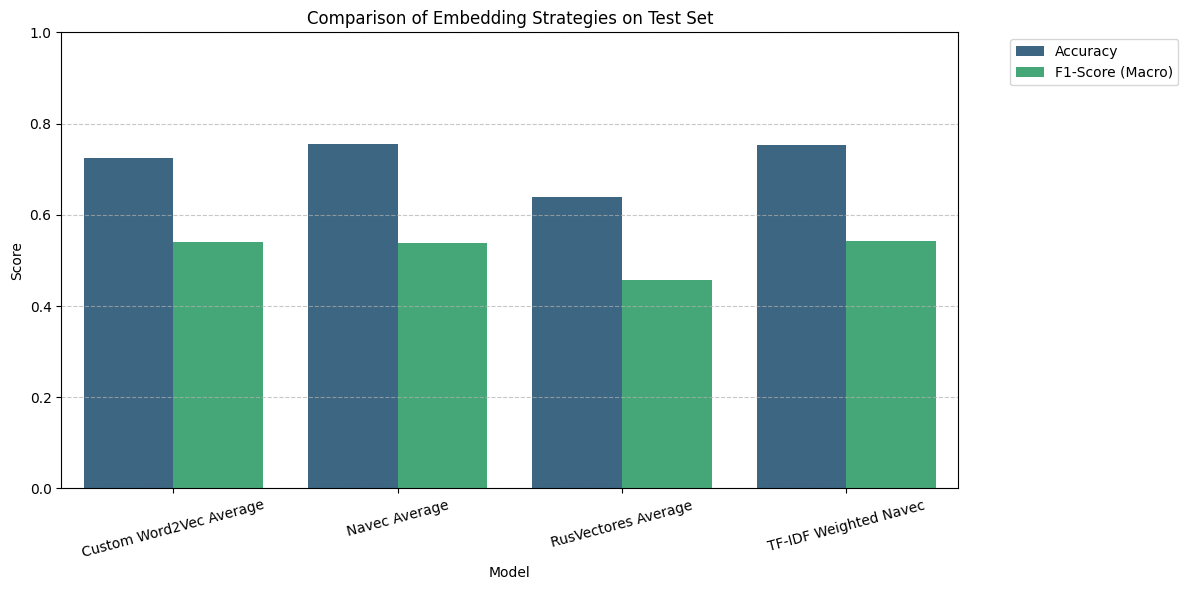

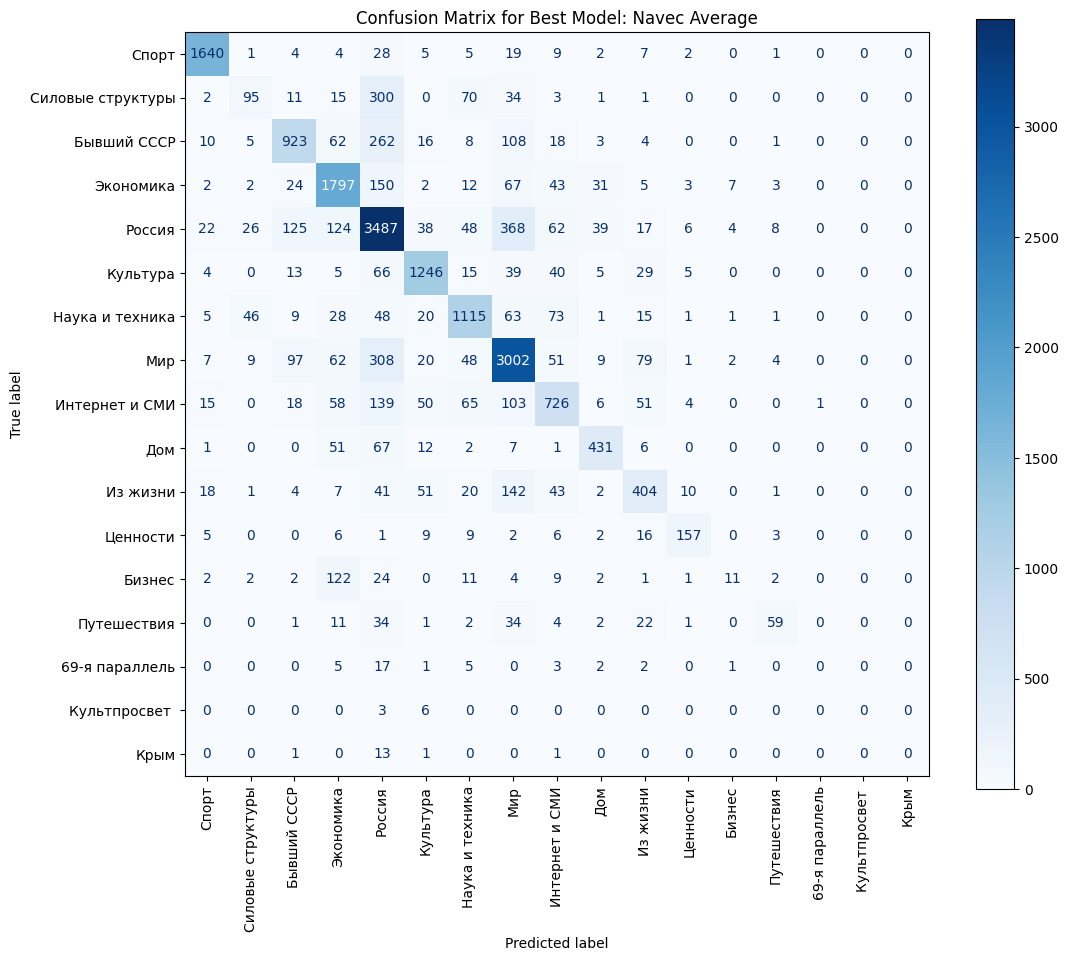

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

df_test_results = pd.DataFrame(test_evaluation_results)
print("Summary Table of Test Results:")
display(df_test_results)

plt.figure(figsize=(12, 6))
df_melted = df_test_results.melt(id_vars='Model', var_name='Metric', value_name='Score')
sns.barplot(data=df_melted, x='Model', y='Score', hue='Metric', palette='viridis')
plt.title('Comparison of Embedding Strategies on Test Set')
plt.ylim(0, 1.0)
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# лучшая модель
best_model_preds = y_pred_navec
best_model_name = "Navec Average"

# Плоты и confusion matrix
cm = confusion_matrix(y_test, best_model_preds, labels=df_train['topic'].unique())
fig, ax = plt.subplots(figsize=(12, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=df_train['topic'].unique())
disp.plot(cmap='Blues', xticks_rotation='vertical', ax=ax, colorbar=True)
plt.title(f'Confusion Matrix for Best Model: {best_model_name}')
plt.show()

# Итого, лучше всего работает Navec взвешанный на TF-IDF